### Research Question 1:

How well do surrogate scores generalize under distributional shift (OOD)
- Can the model predict the ranking correctly?-> spearman
- Can the model predict the actual scores correct -> mse
- Are there systematic biases in OOD regions? -> report bias=mean(pred-true)

These Questions are answered by Scoring two datasets of Sequences. 
1. TFBind8:
    The dataset is split up into train data (lower 50%) to train the models and test data.
2. GB1:
    Scince the GB1 data is just wildtypes with two mutations, new sequences are produced by the Single Mutant Walker to gain data with a higher distance from the training sequences.
In both datasets the distributional shift is measured as minimum hamming distance from the training data. The higher the hamming distance is, the further away are the sequences from the training data. 

Each dataset is scored by both surrogate models: MLP and Random Forest. 


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error
from assets.compute_metrics import compute_model_metrics
from assets.plot import plot_metrics_vs_hamming_distance
import metrics_tfbind8
import metrics_gb1

#### TFBind 8

In [4]:
# Check if results already exist before running metrics computation
PATH = 'results/tfbind8_sequences_scored.csv'
if os.path.exists(PATH):
    print(f"Loading existing results from {PATH}")
    df_tf_results = pd.read_csv(PATH)
else:
    print(f"No existing results found at {PATH}. Running metrics computation.")
    metrics_tfbind8.main()
    df_tf_results = pd.read_csv(PATH)

# Print stats about df_results
print("Summary of results:")
print(df_tf_results.describe())
print(df_tf_results.head(3))

No existing results found at results/tfbind8_sequences_scored.csv. Running metrics computation.
Dataset Loaded and Oracle Initialized. Starting model training and evaluation...
Models trained. Starting evaluation on test set...


/Users/meier/Documents/MasterThesis/metrics_tfbind8.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['min_hamming_distance'] = min_hamming_distance(
  0%|          | 0/64137 [00:00<?, ?it/s]/Users/meier/Documents/MasterThesis/metrics_tfbind8.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data.loc[test_data['sequence'] == seq, 'rf_prediction'] = score_rf
/Users/meier/Documents/MasterThesis/metrics_tfbind8.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slic

Summary of results:
       binding_scores       cluster  ...  rf_prediction  mlp_prediction
count    64137.000000  64137.000000  ...   64137.000000    64137.000000
mean         0.467300     17.588568  ...       0.333135        0.345605
std          0.174734     13.884230  ...       0.032926        0.071199
min          0.000000      0.000000  ...       0.146023        0.046661
25%          0.339958      6.000000  ...       0.313670        0.299515
50%          0.444594     14.000000  ...       0.337854        0.347094
75%          0.570239     27.000000  ...       0.356871        0.393443
max          1.000000     49.000000  ...       0.424259        0.645318

[8 rows x 6 columns]
   sequence  binding_scores  ... rf_prediction  mlp_prediction
0  AAAAAAAA        0.524749  ...      0.383894        0.412691
1  AAAAAAAC        0.366511  ...      0.358424        0.315849
2  AAAAAAAG        0.446759  ...      0.367673        0.373419

[3 rows x 8 columns]


In [5]:
# Compute model metrics
compute_model_metrics(df_tf_results, target_col = 'binding_scores', rf_pred_col='rf_prediction', mlp_pred_col= 'mlp_prediction')


MODEL PERFORMANCE METRICS
        Model Spearman ρ    MSE   Bias Variance
Random Forest     0.3682 0.0457 0.1342   0.0011
          MLP     0.2697 0.0438 0.1217   0.0051



<Axes: title={'center': 'Mean Absolute Error vs Min Hamming Distance'}, xlabel='Min Hamming Distance to Training Set', ylabel='Mean Absolute Error'>

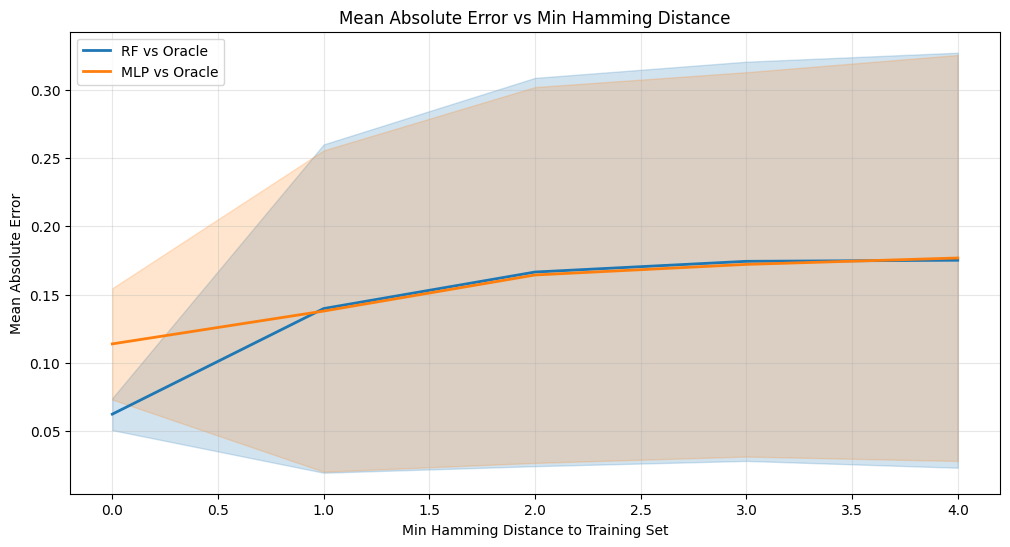

In [7]:
plot_metrics_vs_hamming_distance(df_tf_results, target_col = 'binding_scores', rf_pred_col='rf_prediction', mlp_pred_col= 'mlp_prediction', hamming_col = 'min_hamming_distance')

#### GB1

In [8]:
# Check if results already exist before running metrics computation
PATH = 'results/gb1_generated_sequences_scored.csv'
if os.path.exists(PATH):
    print(f"Loading existing results from {PATH}")
    df_gb_results = pd.read_csv(PATH)
else:
    print(f"No existing results found at {PATH}. Running metrics computation.")
    metrics_gb1.main()
    df_gb_results = pd.read_csv(PATH)

# Print stats about df_results
print("Summary of results:")
print(df_gb_results.describe())
print(df_gb_results.head(3))

Loading existing results from results/gb1_generated_sequences_scored.csv
Summary of results:
       min_hamming_distance  oracle_score  rf_prediction  mlp_prediction
count          56022.000000  56022.000000   56022.000000    56022.000000
mean              10.160776     -2.819095      -6.629210       -5.756415
std                7.851438      3.068266       1.180992        2.488559
min                1.000000    -11.113106      -8.689366      -15.666929
25%                4.000000     -5.449906      -7.518721       -7.483796
50%                8.000000     -2.684820      -6.861625       -5.979722
75%               16.000000     -0.153023      -5.936491       -4.184005
max               33.000000      9.054427      -2.306809        0.323029
                                            sequence  ...  mlp_prediction
0  QYKLILNGKTLKGETTGEAVDAATAEKKFKQYANDNGVDGEHTYDD...  ...       -6.506698
1  QYKLILNGKTPKGETTGEAVDAATAEKKFKQYANDNGVDGEHTYDD...  ...       -6.192511
2  QYKLILNGKTPKGETTGEAVDAATA

In [9]:
compute_model_metrics(df_gb_results, target_col = 'oracle_score', rf_pred_col='rf_prediction', mlp_pred_col= 'mlp_prediction')


MODEL PERFORMANCE METRICS
        Model Spearman ρ     MSE   Bias Variance
Random Forest     0.3293 23.0236 3.8101   1.3947
          MLP     0.6494 14.6292 2.9373   6.1928



<Axes: title={'center': 'Mean Absolute Error vs Min Hamming Distance'}, xlabel='Min Hamming Distance to Training Set', ylabel='Mean Absolute Error'>

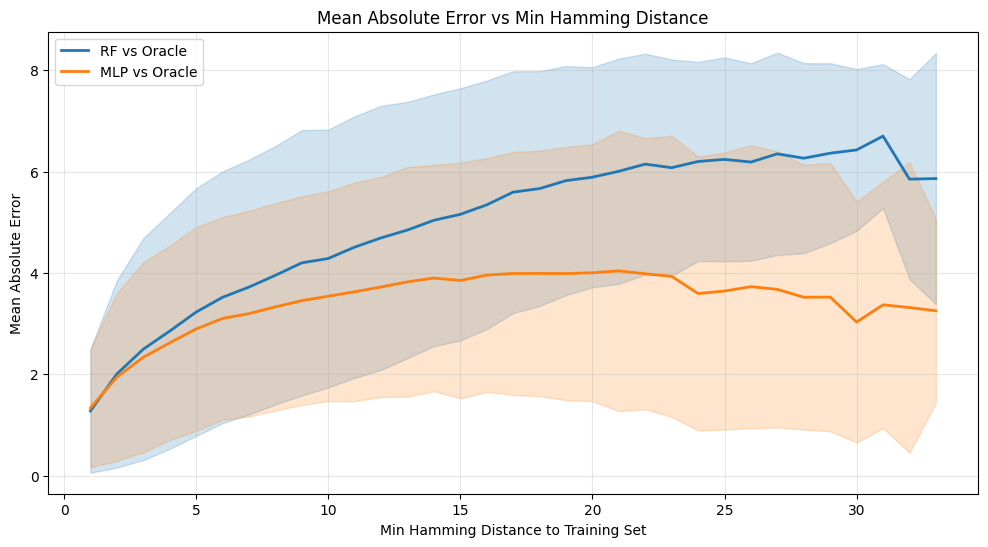

In [10]:
plot_metrics_vs_hamming_distance(df_gb_results, target_col = 'oracle_score', rf_pred_col='rf_prediction', mlp_pred_col= 'mlp_prediction', hamming_col = 'min_hamming_distance')